In [10]:
# Zelle 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)

In [11]:
# Zelle 2
training_data = pd.read_csv("train.csv")
testing_data = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print(training_data.shape, testing_data.shape, sample_submission.shape)
print(sample_submission.columns.tolist())
print(sample_submission.head())

(1460, 81) (1459, 80) (1459, 2)
['Id', 'SalePrice']
     Id      SalePrice
0  1461  169277.052498
1  1462  187758.393989
2  1463  183583.683570
3  1464  179317.477511
4  1465  150730.079977


In [12]:
# Zelle 3
train_indexed = training_data.set_index("Id")
y_full = train_indexed["SalePrice"]
X_full_raw = train_indexed.drop(columns="SalePrice")

X_train_raw, X_holdout_raw, y_train, y_holdout = train_test_split(
    X_full_raw, y_full, test_size=0.2, random_state=123
)

cv = KFold(n_splits=5, shuffle=True, random_state=123)

y_train_log = np.log1p(y_train)
y_holdout_log = np.log1p(y_holdout)

In [13]:
# Zelle 4
dummy_scores = cross_val_score(
    DummyRegressor(strategy="median"),
    X_train_raw[["OverallQual"]], y_train_log,  # Feature hier irrelevant, Dummy ignoriert es ohnehin
    cv=cv, scoring="neg_root_mean_squared_error"
)
print("Dummy-Median RMSLE:", -dummy_scores.mean(), "±", dummy_scores.std())

Dummy-Median RMSLE: 0.4040904365924459 ± 0.01893350809327312


In [14]:
# Zelle 5
mini_features = ["OverallQual", "GrLivArea"]
mini_scores = cross_val_score(
    LinearRegression(), X_train_raw[mini_features], y_train_log,
    cv=cv, scoring="neg_root_mean_squared_error"
)
print("Mini-Modell RMSLE:", -mini_scores.mean(), "±", mini_scores.std())

Mini-Modell RMSLE: 0.2068248472652309 ± 0.015617574452935906


In [15]:
# Zelle 6
for outlier_id in [524, 1299]:
    in_train = outlier_id in X_train_raw.index
    print(outlier_id, "im Trainingssplit" if in_train else "im Holdout-Split",
          "| GrLivArea:", X_full_raw.loc[outlier_id, "GrLivArea"],
          "| SalePrice:", y_full.loc[outlier_id])

524 im Trainingssplit | GrLivArea: 4676 | SalePrice: 184750
1299 im Trainingssplit | GrLivArea: 5642 | SalePrice: 160000


In [16]:
# Zelle 7
print("Train/Test gleiche Feature-Menge:",
      set(X_full_raw.columns) == set(testing_data.drop(columns="Id").columns))
print("Doppelte Train-IDs:", training_data["Id"].duplicated().sum())
print("Doppelte Test-IDs:", testing_data["Id"].duplicated().sum())

display(X_train_raw.isna().sum().sort_values(ascending=False).head(20))
display(X_train_raw.dtypes.value_counts())

Train/Test gleiche Feature-Menge: True
Doppelte Train-IDs: 0
Doppelte Test-IDs: 0


PoolQC          1161
MiscFeature     1125
Alley           1092
Fence            940
MasVnrType       700
FireplaceQu      555
LotFrontage      189
GarageCond        67
GarageType        67
GarageYrBlt       67
GarageQual        67
GarageFinish      67
BsmtExposure      30
BsmtFinType2      29
BsmtFinType1      29
BsmtCond          29
BsmtQual          29
MasVnrArea         4
Electrical         1
KitchenAbvGr       0
dtype: int64

str        43
int64      33
float64     3
Name: count, dtype: int64

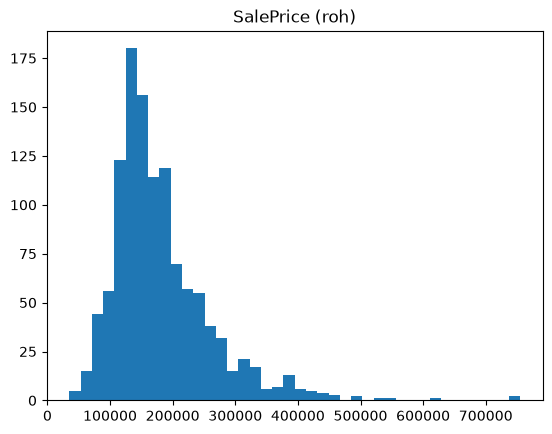

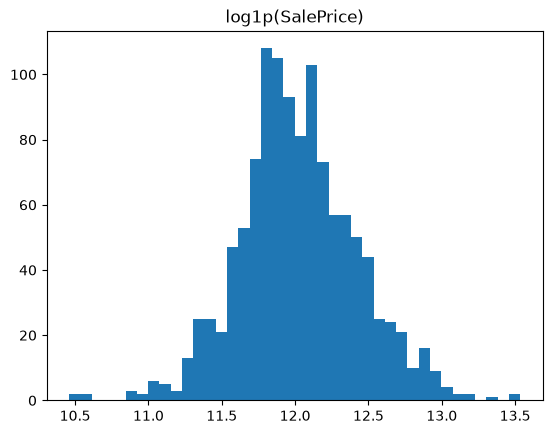

In [17]:
# Zelle 8
plt.figure()
plt.hist(y_train, bins=40)
plt.title("SalePrice (roh)")

plt.figure()
plt.hist(y_train_log, bins=40)
plt.title("log1p(SalePrice)")
plt.show()

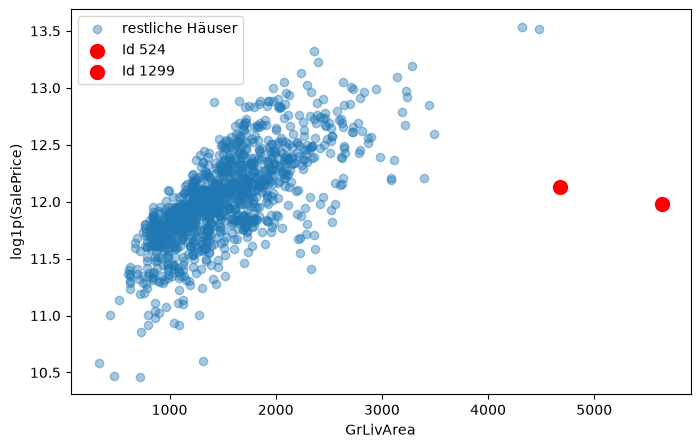

In [18]:
# Zelle 9
plt.figure(figsize=(8,5))
plt.scatter(X_train_raw["GrLivArea"], y_train_log, alpha=0.4, label="restliche Häuser")
for outlier_id in [524, 1299]:
    if outlier_id in X_train_raw.index:
        plt.scatter(X_train_raw.loc[outlier_id, "GrLivArea"], y_train_log.loc[outlier_id], color="red", s=100, label=f"Id {outlier_id}")
plt.xlabel("GrLivArea")
plt.ylabel("log1p(SalePrice)")
plt.legend()
plt.show()